In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
import numpy as np
import pandas as pd
from IPython.display import display_html
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

 
imdb, info = tfds.load("imdb_reviews", with_info=True, as_supervised=True, data_dir="./data/", download=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling data/imdb_reviews/plain_text/incomplete.1O1GJ7_1.0.0/imdb_reviews-train.tfrecord*...:   0%|         …

Generating test examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling data/imdb_reviews/plain_text/incomplete.1O1GJ7_1.0.0/imdb_reviews-test.tfrecord*...:   0%|          …

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling data/imdb_reviews/plain_text/incomplete.1O1GJ7_1.0.0/imdb_reviews-unsupervised.tfrecord*...:   0%|  …

Dataset imdb_reviews downloaded and prepared to data/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [2]:
print(info)

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir=PosixGPath('/tmp/tmp44qawlmetfds'),
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=25000, num_shards=1>,
        'train': <SplitInfo

In [3]:
for example in imdb['train'].take(1):
  print(example)

(<tf.Tensor: shape=(), dtype=string, numpy=b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.">, <tf.Tensor: shape=(), dtype=int64, numpy=0>)


In [4]:
train_dataset, test_dataset = imdb['train'], imdb['test']

# Parameters for generating Padded Sequences
VOCAB_SIZE = 10000
MAX_LENGTH = 120
EMBEDDING_DIM = 16
PADDING_TYPE = 'pre'
TRUNC_TYPE = 'post'

In [5]:
vectorize_layer = tf.keras.layers.TextVectorization( max_tokens = VOCAB_SIZE, )

train_reviews = train_dataset.map(lambda review, label: review)
train_labels = train_dataset.map(lambda review, label: label)

test_reviews = test_dataset.map(lambda review, label: review)
test_labels = test_dataset.map(lambda review, label: label)

vectorize_layer.adapt(train_reviews) # Generate the vocabulary based only on the training set

In [6]:
def padding_func(sequences):
  '''Generates padded sequences from a tf.data.Dataset'''

  # Put all elements in a single ragged batch
  # Output a tensor from the single batch
    
  sequences = sequences.ragged_batch(batch_size=sequences.cardinality())
  sequences = sequences.get_single_element()

  # Pad the sequences
  padded_sequences = tf.keras.utils.pad_sequences(sequences.numpy(), 
                                                  maxlen=MAX_LENGTH, 
                                                  truncating=TRUNC_TYPE, 
                                                  padding=PADDING_TYPE
                                                 )

  # Convert back to a tf.data.Dataset
  padded_sequences = tf.data.Dataset.from_tensor_slices(padded_sequences)

  return padded_sequences

train_sequences = train_reviews.map(lambda text: vectorize_layer(text)).apply(padding_func)
test_sequences = test_reviews.map(lambda text: vectorize_layer(text)).apply(padding_func)

In [7]:
for example in train_sequences.take(1):
  print(example)

tf.Tensor(
[   0    0    0    0   11   14   34  412  384   18   90   28    1    8
   33 1322 3560   42  487    1  191   24   85  152   19   11  217  316
   28   65  240  214    8  489   54   65   85  112   96   22 5596   11
   93  642  743   11   18    7   34  394 9522  170 2464  408    2   88
 1216  137   66  144   51    2    1 7558   66  245   65 2870   16    1
 2860    1    1 1426 5050    3   40    1 1579   17 3560   14  158   19
    4 1216  891 8040    8    4   18   12   14 4059    5   99  146 1241
   10  237  704   12   48   24   93   39   11 7339  152   39 1322    1
   50  398   10   96 1155  851  141    9], shape=(120,), dtype=int32)


In [8]:
train_dataset_vectorized = tf.data.Dataset.zip(train_sequences,train_labels)
test_dataset_vectorized = tf.data.Dataset.zip(test_sequences,test_labels)

In [9]:
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Optimize the datasets for training
train_dataset_final = (train_dataset_vectorized
                       .cache()
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .prefetch(PREFETCH_BUFFER_SIZE)
                       .batch(BATCH_SIZE)
                       )

test_dataset_final = (test_dataset_vectorized
                      .cache()
                      .prefetch(PREFETCH_BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      )

In [10]:
EMBEDDING_DIM = 64
LSTM1_DIM = 32
LSTM2_DIM = 16
DENSE_DIM = 64

# Build the model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(None,)),
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM1_DIM, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM2_DIM)),
    tf.keras.layers.Dense(DENSE_DIM, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
]) 

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, None, 64)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, None, 64)            │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 32)                  │          10,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 677,377 (2.58 MB)

 Trainable params: 677,377 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
NUM_EPOCHS = 10

history = model.fit(train_dataset_final, epochs=NUM_EPOCHS, validation_data=test_dataset_final)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.6835 - loss: 0.5488 - val_accuracy: 0.8297 - val_loss: 0.3796
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.8832 - loss: 0.2862 - val_accuracy: 0.8226 - val_loss: 0.4433
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9338 - loss: 0.1793 - val_accuracy: 0.8091 - val_loss: 0.5132
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9604 - loss: 0.1092 - val_accuracy: 0.7944 - val_loss: 0.6770
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9755 - loss: 0.0700 - val_accuracy: 0.7953 - val_loss: 0.7791
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9832 - loss: 0.0477 - val_accuracy: 0.8006 - val_loss: 0.9416
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9886 - loss: 0.0333 - val_accuracy: 0.7964 - val_loss: 1.0578
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9893 - loss: 0.0288 - 

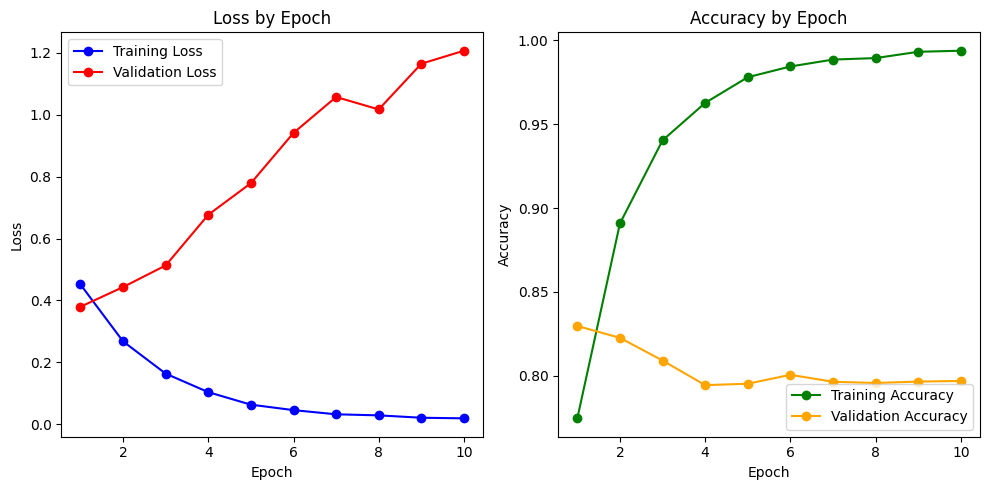

In [12]:
epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 5)) 
# Plot Loss: Training vs. Validation
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], marker='o', color='blue', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], marker='o', color='red', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss by Epoch')
plt.legend()

# Plot Accuracy: Training vs. Validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'], marker='o', color='green', label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], marker='o', color='orange', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy by Epoch')
plt.legend()

plt.tight_layout()
plt.show()

Starting evaluation...


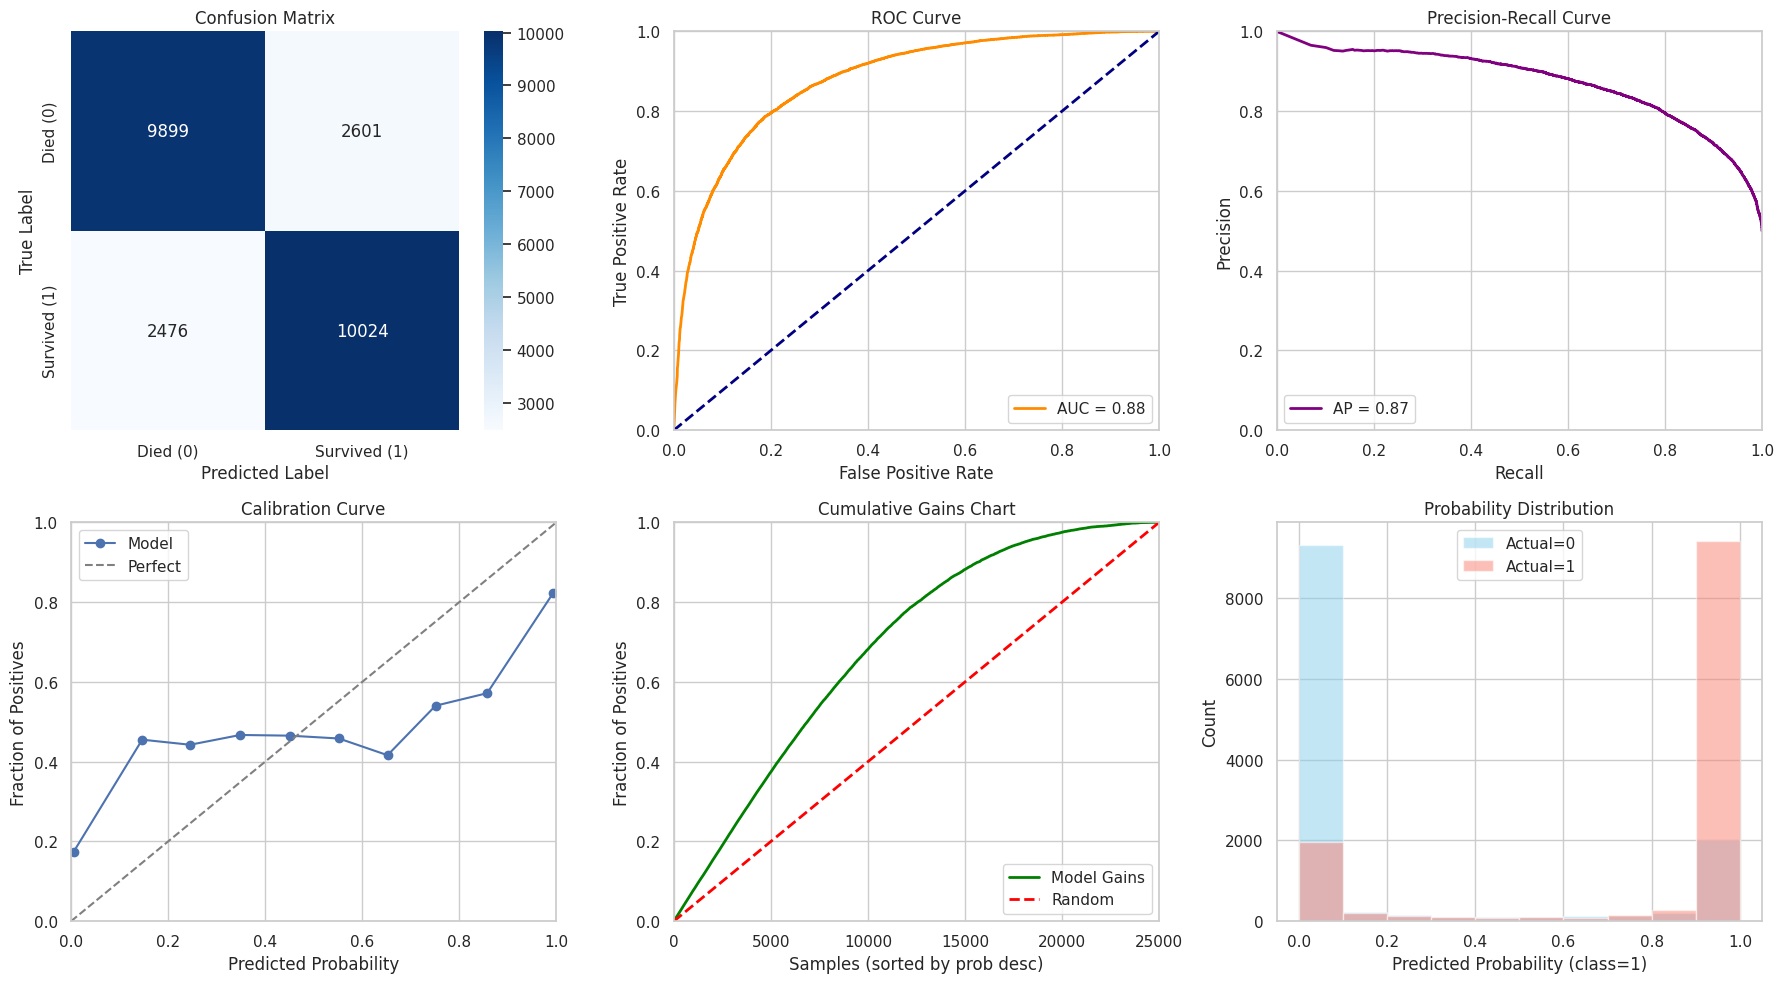

In [13]:
import os
# Suppress TensorFlow INFO and WARNING messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
 
# test_dataset_final was batches of (padded_sequences, labels)
 

print("Starting evaluation...")
 
# 1) Extract true labels and predictions from test_dataset_final 
# Convert test labels to a NumPy array
y_true = np.concatenate([label.numpy() for x, label in test_dataset_final])

# Get predicted probabilities (suppressing verbose output)
y_prob = np.concatenate([model.predict(x, verbose=0).flatten() for x, label in test_dataset_final])

# Convert probabilities to binary predictions (threshold=0.5)
y_pred = (y_prob > 0.5).astype(int)
 
# 2) Error Analysis: Display Misclassified Samples 

errors_df = pd.DataFrame({
    "TrueLabel": y_true,
    "PredLabel": y_pred,
    "PredProb": y_prob
})
errors_df["Correct"] = errors_df["TrueLabel"] == errors_df["PredLabel"]

#print("=== MISCLASSIFIED SAMPLES (FIRST 10) ===")
#display(errors_df[~errors_df["Correct"]].head(10))

# -----------------------------------------------------
# 3) Create a 2×3 Grid of Evaluation Plots
# -----------------------------------------------------
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# (a) Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died (0)", "Survived (1)"],
            yticklabels=["Died (0)", "Survived (1)"],
            ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted Label")
axes[0, 0].set_ylabel("True Label")

# (b) ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
roc_auc = roc_auc_score(y_true, y_prob)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_ylim([0, 1])
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].legend(loc="lower right")

# (c) Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
avg_precision = average_precision_score(y_true, y_prob)
axes[0, 2].plot(recall, precision, color='purple', lw=2, label=f"AP = {avg_precision:.2f}")
axes[0, 2].set_xlim([0, 1])
axes[0, 2].set_ylim([0, 1])
axes[0, 2].set_xlabel("Recall")
axes[0, 2].set_ylabel("Precision")
axes[0, 2].set_title("Precision-Recall Curve")
axes[0, 2].legend(loc="lower left")

# (d) Calibration Curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
axes[1, 0].plot(prob_pred, prob_true, marker='o', label="Model")
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', label="Perfect")
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])
axes[1, 0].set_xlabel("Predicted Probability")
axes[1, 0].set_ylabel("Fraction of Positives")
axes[1, 0].set_title("Calibration Curve")
axes[1, 0].legend()

# (e) Cumulative Gains Chart
df_eval = pd.DataFrame({"TrueLabel": y_true, "Prob": y_prob})
df_eval = df_eval.sort_values("Prob", ascending=False).reset_index(drop=True)
df_eval["CumulativePos"] = (df_eval["TrueLabel"] == 1).cumsum()
df_eval["CumulativeCount"] = np.arange(1, len(df_eval) + 1)
total_positives = (df_eval["TrueLabel"] == 1).sum()
df_eval["Gains"] = df_eval["CumulativePos"] / total_positives
axes[1, 1].plot(df_eval["CumulativeCount"], df_eval["Gains"], color="green", lw=2, label="Model Gains")
axes[1, 1].plot([0, len(df_eval)], [0, 1], color="red", lw=2, linestyle="--", label="Random")
axes[1, 1].set_xlim([0, len(df_eval)])
axes[1, 1].set_ylim([0, 1])
axes[1, 1].set_xlabel("Samples (sorted by prob desc)")
axes[1, 1].set_ylabel("Fraction of Positives")
axes[1, 1].set_title("Cumulative Gains Chart")
axes[1, 1].legend(loc="lower right")

# (f) Predicted Probability Distribution
axes[1, 2].hist(y_prob[y_true==0], bins=10, alpha=0.5, label="Actual=0", color='skyblue')
axes[1, 2].hist(y_prob[y_true==1], bins=10, alpha=0.5, label="Actual=1", color='salmon')
axes[1, 2].set_xlabel("Predicted Probability (class=1)")
axes[1, 2].set_ylabel("Count")
axes[1, 2].set_title("Probability Distribution")
axes[1, 2].legend(loc="upper center")

plt.tight_layout()
plt.show()

##############################################################################################################################
##############################################################################################################################

import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

# -------------------------------
# 1) Confusion Matrix and Derived Metrics
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()
total = TN + FP + FN + TP

confusion_df = pd.DataFrame({
    "Metric": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Count": [TN, FP, FN, TP],
    "Percentage (%)": [TN/total*100, FP/total*100, FN/total*100, TP/total*100]
})

accuracy = (TP + TN) / total
precision_metric = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall_metric = TP / (TP + FN) if (TP + FN) > 0 else np.nan
f1_metric = (2 * precision_metric * recall_metric / (precision_metric + recall_metric)
             if (precision_metric + recall_metric) > 0 else np.nan)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision_metric, recall_metric, f1_metric]
})

# -------------------------------
# 2) ROC Decile Data
# -------------------------------
percentiles = np.arange(10, 101, 10)
roc_decile_list = []
for p in percentiles:
    thresh = np.percentile(y_prob, p)
    y_decile_pred = (y_prob >= thresh).astype(int)
    cm_d = confusion_matrix(y_true, y_decile_pred)
    TN_d, FP_d, FN_d, TP_d = cm_d.ravel()
    fpr_d = FP_d / (FP_d + TN_d) if (FP_d + TN_d) > 0 else np.nan
    tpr_d = TP_d / (TP_d + FN_d) if (TP_d + FN_d) > 0 else np.nan
    roc_decile_list.append([f"{p}%", thresh, fpr_d, tpr_d])
roc_decile_df = pd.DataFrame(roc_decile_list, columns=["Percentile", "Threshold", "FPR", "TPR"])
roc_auc = roc_auc_score(y_true, y_prob)

# -------------------------------
# 3) Precision-Recall Decile Data
# -------------------------------
pr_decile_list = []
for p in percentiles:
    thresh = np.percentile(y_prob, p)
    y_decile_pred = (y_prob >= thresh).astype(int)
    cm_d = confusion_matrix(y_true, y_decile_pred)
    TN_d, FP_d, FN_d, TP_d = cm_d.ravel()
    prec_d = TP_d / (TP_d + FP_d) if (TP_d + FP_d) > 0 else np.nan
    rec_d = TP_d / (TP_d + FN_d) if (TP_d + FN_d) > 0 else np.nan
    pr_decile_list.append([f"{p}%", thresh, prec_d, rec_d])
pr_decile_df = pd.DataFrame(pr_decile_list, columns=["Percentile", "Threshold", "Precision", "Recall"])
avg_precision = average_precision_score(y_true, y_prob)

# -------------------------------
# 4) Calibration Data (Quantile Binning)
# -------------------------------
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='quantile')
calib_df = pd.DataFrame({
    "Bin Predicted Probability": prob_pred,
    "Fraction of Positives": prob_true
})

# -------------------------------
# 5) Cumulative Gains Decile Data
# -------------------------------
df_eval = pd.DataFrame({"TrueLabel": y_true, "Prob": y_prob})
df_eval = df_eval.sort_values("Prob", ascending=False).reset_index(drop=True)
df_eval["CumulativePos"] = (df_eval["TrueLabel"] == 1).cumsum()
df_eval["CumulativeCount"] = np.arange(1, len(df_eval) + 1)
total_positives = (df_eval["TrueLabel"] == 1).sum()
df_eval["Gains"] = df_eval["CumulativePos"] / total_positives
gains_decile_list = []
N = len(df_eval)
for p in percentiles:
    idx = int(np.ceil(p/100 * N)) - 1  # 0-based index
    row = df_eval.iloc[idx]
    gains_decile_list.append([f"{p}%", row["CumulativeCount"], row["CumulativePos"], row["Gains"]])
gains_decile_df = pd.DataFrame(gains_decile_list, columns=["Percentile", "CumulativeCount", "CumulativePos", "Gains"])

# -------------------------------
# 6) Aggregate Metrics
# -------------------------------
agg_df = pd.DataFrame({
    "Metric": ["Overall Accuracy", "Overall AUC", "Average Precision"],
    "Value": [accuracy, roc_auc, avg_precision]
})

# -------------------------------
# Helper Function: Convert DataFrame to HTML with Centered Title (No Borders)
# -------------------------------
def df_to_html_with_title(df, title):
    html = f"<h4 style='text-align: center; margin-bottom: 5px;'>{title}</h4>"
    html += df.to_html(index=False, border=0)
    return html

# -------------------------------
# Create HTML for each table
# -------------------------------
table1 = df_to_html_with_title(confusion_df, "Confusion Matrix")
table2 = df_to_html_with_title(metrics_df, "Derived Metrics")
table3 = df_to_html_with_title(roc_decile_df, "ROC Decile Data")
table4 = df_to_html_with_title(pr_decile_df, "Precision-Recall Decile Data")
table5 = df_to_html_with_title(calib_df, "Calibration Data")
table6 = df_to_html_with_title(gains_decile_df, "Cumulative Gains Decile Data")
table7 = df_to_html_with_title(agg_df, "Aggregate Metrics")

# -------------------------------
# Arrange Tables in a Grid (3 per row) using HTML table layout
# -------------------------------
combined_html = f"""
<table style="width:100%; border-collapse:collapse;">
  <tr>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table1}</td>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table2}</td>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table3}</td>
  </tr>
  <tr>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table4}</td>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table5}</td>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table6}</td>
  </tr>
  <tr>
    <td style="vertical-align:top; width:33%; padding: 5px;">{table7}</td>
    <td style="vertical-align:top; width:33%; padding: 5px;"></td>
    <td style="vertical-align:top; width:33%; padding: 5px;"></td>
  </tr>
</table>
"""

display(HTML(combined_html))

In [14]:
# Get the embedding layer from the model (i.e. first layer)
embedding_layer = model.layers[0]

# Get the weights of the embedding layer
embedding_weights = embedding_layer.get_weights()[0]

# Print the shape. Expected is (vocab_size, embedding_dim)
print(embedding_weights.shape)

(10000, 64)


In [15]:
# Open writeable files
out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')

# Get the word list
vocabulary = vectorize_layer.get_vocabulary()

# Initialize the loop. Start counting at `1` because `0` is just for the padding
for word_num in range(1, len(vocabulary)):

  # Get the word associated withAttributeError the current index
  word_name = vocabulary[word_num]

  # Get the embedding weights associated with the current index
  word_embedding = embedding_weights[word_num]

  # Write the word name
  out_m.write(word_name + "\n")

  # Write the word embedding
  out_v.write('\t'.join([str(x) for x in word_embedding]) + "\n")

# Close the files
out_v.close()
out_m.close()

In [16]:
print(os.listdir('.'))

['data', 'vecs.tsv', '__notebook__.ipynb', 'meta.tsv']
